# Regularized Regression


## Notebook Objective

This notebook compares baseline Linear Regression with Ridge Regression and Lasso Regression for monthly cost prediction.

The goal is to understand whether regularization improves model generalization or creates more stable coefficients compared with the unregularized baseline model.

This notebook is not mainly about improving performance. It is about learning how coefficient shrinkage works and whether Ridge or Lasso meaningfully changes model behavior in this synthetic healthcare cost dataset.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv")

print(df.shape)
df.head()



(3000, 25)


,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and Features


In [3]:
target = "monthly_cost"  # Define the regression target variable

drop_cols = [
    "member_id",
    target,
    "high_cost_member",
    "awv_completed",

    # Drop full-dataset quartile / grouped features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",

    # Drop redundant utilization features
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Drop duplicate prior AWV representation
    "prior_awv_count"
]

X = df.drop(columns=drop_cols, errors="ignore")  # Create predictors after removing leakage-prone columns
y = df[target]  # Store monthly cost as the regression target

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric predictors for scaling
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like predictors for encoding
).columns.tolist()

## 4. Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # Split data into training and testing sets (80% train, 20% test) with a fixed random state for reproducibility


## 5. Build Preprocessing

In [5]:
preprocessor = ColumnTransformer( 
    transformers = [
        ("num", StandardScaler(), numeric_cols), # Scale numeric features using StandardScaler (mean=0, std=1)
        ("cat", OneHotEncoder(drop = "first", handle_unknown = "ignore"), categorical_cols) # Encode categorical features using OneHotEncoder, dropping the first category to avoid multicollinearity and ignoring unknown categories in test data
    ]
)

## 6. Build three models

In [6]:
linear_model = Pipeline(steps = [
    ("preprocessor", preprocessor), # Apply preprocessing steps defined in the preprocessor
    ("regressor", LinearRegression()) # Fit a Linear Regression model
])

ridge_model = Pipeline(steps = [
    ("preprocessor", preprocessor), # Apply preprocessing steps defined in the preprocessor
    ("regressor", Ridge(alpha = 1.0)) # Fit a Ridge Regression model with alpha=1.0 (L2 regularization)
])

lasso_model = Pipeline(steps = [
    ("preprocessor", preprocessor), # Apply preprocessing steps defined in the preprocessor
    ("regressor", Lasso(alpha = 0.1, max_iter = 10000)) # Fit Lasso regression with L1 regularization
]) # Testing whether L1 regularization creates sparsity.

## Why Compare Linear Regression, Ridge, and Lasso?

Linear Regression estimates coefficients without a penalty term. This can work well when predictors are not highly collinear and the model is simple.

Ridge Regression adds an L2 penalty. This shrinks coefficients toward zero but usually does not set them exactly to zero. Ridge is useful when predictors are correlated or when coefficient stability matters.

Lasso Regression adds an L1 penalty. This can shrink some coefficients exactly to zero, which makes it useful for feature selection. However, Lasso can be unstable when predictors are correlated.

The regularization strength is controlled by `alpha`.

- Higher `alpha` means stronger shrinkage.
- Lower `alpha` means weaker shrinkage.
- `alpha = 0` behaves like unregularized Linear Regression, but sklearn recommends using `LinearRegression` instead of setting alpha to zero.

In this notebook, Ridge uses `alpha = 1.0` and Lasso uses `alpha = 0.1` as simple starting values.

## 7. Fit all models

In [7]:
linear_model.fit(X_train, y_train) # Fit the Linear Regression model on the training data
ridge_model.fit(X_train, y_train) # Fit the Ridge Regression model on the training data
lasso_model.fit(X_train, y_train) # Fit the Lasso Regression model on the training data



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## 8. Evaluate all models

In [8]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test) # Generate predictions on the test set 
    
    mae = mean_absolute_error(y_test, y_pred) # Calculate Mean Absolute Error
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calculate Root Mean Squared Error
    r2 = r2_score(y_test, y_pred) # Calculate R-squared score

    return pd.DataFrame({
        "model" : [model_name], # Name of the model being evaluated
        "MAE" : [mae], # Mean Absolute Error
        "RMSE" : [rmse], # Root Mean Squared Error
        "R2" : [r2] # R-squared score
    })

results_df = pd.concat([
    evaluate_model(linear_model, X_test, y_test, "Linear Regression"), # Evaluate Linear Regression model and add results to the results DataFrame
    evaluate_model(ridge_model, X_test, y_test, "Ridge Regression"), # Evaluate Ridge Regression model and add results to the results DataFrame
    evaluate_model(lasso_model, X_test, y_test, "Lasso Regression") # Evaluate Lasso Regression model and add results to the results DataFrame
], ignore_index = True) # Concatenate results into a single DataFrame and reset index


results_df 

,model,MAE,RMSE,R2
0,Linear Regression,404.199693,654.268918,0.763852
1,Ridge Regression,404.168808,654.238079,0.763874
2,Lasso Regression,404.141219,654.207717,0.763896


## Model Performance Interpretation

All three models perform almost identically.

Lasso has the slightly best MAE, RMSE, and R², but the difference is extremely small. The improvement is not practically meaningful.

This suggests that, with the current feature set, regularization does not materially improve prediction performance compared with baseline Linear Regression.

That is not a failure. It likely means the current model has a small number of clean predictors and does not have severe overfitting pressure.

## 9. Extract coefficient for comparison 

In [9]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out() # Get the names of the features after preprocessing (including one-hot encoded features)
linear_coefs = linear_model.named_steps["regressor"].coef_ # Get the coefficients from the Linear Regression model
ridge_coefs = ridge_model.named_steps["regressor"].coef_ # Get the coefficients from the Ridge Regression model
lasso_coefs = lasso_model.named_steps["regressor"].coef_ # Get the coefficients from the Lasso Regression model

coef_comparison = pd.DataFrame ({
    "feature" : feature_names,
    "linear_coef" : linear_coefs,
    "ridge_coef" : ridge_coefs,
    "lasso_coef" : lasso_coefs
})

coef_comparison["linear_coef_abs"] = coef_comparison["linear_coef"].abs() # Calculate absolute values of Linear Regression coefficients for easier comparison
coef_comparison["ridge_coef_abs"] = coef_comparison["ridge_coef"].abs() # Calculate absolute values of Ridge Regression coefficients for easier comparison
coef_comparison["lasso_coef_abs"] = coef_comparison["lasso_coef"].abs() # Calculate absolute values of Lasso Regression coefficients for easier comparison  


coef_comparison["ridge_abs_shrinkage"] = (
    coef_comparison["linear_coef_abs"] - coef_comparison["ridge_coef_abs"]
)  # Positive value means Ridge reduced coefficient magnitude compared with Linear Regression

coef_comparison["lasso_abs_shrinkage"] = (
    coef_comparison["linear_coef_abs"] - coef_comparison["lasso_coef_abs"]
)  # Positive value means Lasso reduced coefficient magnitude compared with Linear Regression

coef_comparison.sort_values(
    "lasso_abs_shrinkage",  # Sort by strongest Lasso magnitude reduction
    ascending=False
).head(20)

,feature,linear_coef,ridge_coef,lasso_coef,linear_coef_abs,ridge_coef_abs,lasso_coef_abs,ridge_abs_shrinkage,lasso_abs_shrinkage
12,cat__plan_type_Medicare Advantage,-417.503901,-413.585467,-415.083380,417.503901,413.585467,415.083380,3.918434,2.420521
9,cat__region_Suburban,-48.937854,-47.865148,-46.725396,48.937854,47.865148,46.725396,1.072706,2.212457
11,cat__plan_type_Medicaid,-545.995977,-542.425961,-544.049212,545.995977,542.425961,544.049212,3.570015,1.946765
10,cat__region_Urban,-105.978163,-105.399607,-104.563988,105.978163,105.399607,104.563988,0.578556,1.414174
1,num__sdoh_risk_score,-4.501480,-4.023907,-3.866957,4.501480,4.023907,3.866957,0.477573,0.634522
8,cat__gender_Male,-13.977935,-13.951679,-13.542621,13.977935,13.951679,13.542621,0.026256,0.435315
5,num__prior_awv_rate,11.236872,11.229452,11.063638,11.236872,11.229452,11.063638,0.007420,0.173234
7,num__ip_admits,579.390145,579.152242,579.305688,579.390145,579.152242,579.305688,0.237903,0.084457
0,num__age,63.194242,63.403640,63.137719,63.194242,63.403640,63.137719,-0.209398,0.056523
4,num__pcp_attributed_24mo,-39.571305,-39.621657,-39.516952,39.571305,39.621657,39.516952,-0.050353,0.054353


## Coefficient Shrinkage Interpretation

The coefficient comparison table shows how much Ridge and Lasso changed each coefficient relative to Linear Regression.

Ridge slightly shrinks coefficients toward zero, but the changes are small.

Lasso also slightly shrinks coefficients, but with `alpha = 0.1`, it does not set any coefficients exactly to zero.

Because numeric predictors were standardized, numeric coefficients can be compared more fairly with each other. However, categorical dummy coefficients are still interpreted relative to their omitted reference category.

Coefficient shrinkage should be interpreted as a modeling stability tool, not as causal evidence.

## 10. Compare Coefficient Shrinkage

In [10]:
coef_comparison.sort_values(
    "linear_coef_abs",  # Sort by original Linear Regression coefficient magnitude
    ascending=False  # Show largest absolute coefficients first
).head(20)  # Display top coefficients before regularization

,feature,linear_coef,ridge_coef,lasso_coef,linear_coef_abs,ridge_coef_abs,lasso_coef_abs,ridge_abs_shrinkage,lasso_abs_shrinkage
2,num__chronic_condition_count,685.326198,684.973452,685.302629,685.326198,684.973452,685.302629,0.352746,0.023569
7,num__ip_admits,579.390145,579.152242,579.305688,579.390145,579.152242,579.305688,0.237903,0.084457
11,cat__plan_type_Medicaid,-545.995977,-542.425961,-544.049212,545.995977,542.425961,544.049212,3.570015,1.946765
12,cat__plan_type_Medicare Advantage,-417.503901,-413.585467,-415.083380,417.503901,413.585467,415.083380,3.918434,2.420521
6,num__ed_visits,261.574043,261.628722,261.536694,261.574043,261.628722,261.536694,-0.054680,0.037349
10,cat__region_Urban,-105.978163,-105.399607,-104.563988,105.978163,105.399607,104.563988,0.578556,1.414174
0,num__age,63.194242,63.403640,63.137719,63.194242,63.403640,63.137719,-0.209398,0.056523
3,num__engagement_score,-62.284947,-62.302204,-62.286736,62.284947,62.302204,62.286736,-0.017256,-0.001788
9,cat__region_Suburban,-48.937854,-47.865148,-46.725396,48.937854,47.865148,46.725396,1.072706,2.212457
4,num__pcp_attributed_24mo,-39.571305,-39.621657,-39.516952,39.571305,39.621657,39.516952,-0.050353,0.054353


In [11]:
coef_comparison.sort_values(
    "lasso_abs_shrinkage",  # Sort by strongest Lasso magnitude reduction
    ascending=False  # Show most reduced coefficients first
).head(20)  # Display features most shrunk by Lasso

,feature,linear_coef,ridge_coef,lasso_coef,linear_coef_abs,ridge_coef_abs,lasso_coef_abs,ridge_abs_shrinkage,lasso_abs_shrinkage
12,cat__plan_type_Medicare Advantage,-417.503901,-413.585467,-415.083380,417.503901,413.585467,415.083380,3.918434,2.420521
9,cat__region_Suburban,-48.937854,-47.865148,-46.725396,48.937854,47.865148,46.725396,1.072706,2.212457
11,cat__plan_type_Medicaid,-545.995977,-542.425961,-544.049212,545.995977,542.425961,544.049212,3.570015,1.946765
10,cat__region_Urban,-105.978163,-105.399607,-104.563988,105.978163,105.399607,104.563988,0.578556,1.414174
1,num__sdoh_risk_score,-4.501480,-4.023907,-3.866957,4.501480,4.023907,3.866957,0.477573,0.634522
8,cat__gender_Male,-13.977935,-13.951679,-13.542621,13.977935,13.951679,13.542621,0.026256,0.435315
5,num__prior_awv_rate,11.236872,11.229452,11.063638,11.236872,11.229452,11.063638,0.007420,0.173234
7,num__ip_admits,579.390145,579.152242,579.305688,579.390145,579.152242,579.305688,0.237903,0.084457
0,num__age,63.194242,63.403640,63.137719,63.194242,63.403640,63.137719,-0.209398,0.056523
4,num__pcp_attributed_24mo,-39.571305,-39.621657,-39.516952,39.571305,39.621657,39.516952,-0.050353,0.054353


In [12]:
coef_comparison.sort_values(
    "ridge_abs_shrinkage",  # Sort by strongest Ridge magnitude reduction
    ascending=False  # Show most reduced coefficients first
).head(20)  # Display features most shrunk by Ridge

,feature,linear_coef,ridge_coef,lasso_coef,linear_coef_abs,ridge_coef_abs,lasso_coef_abs,ridge_abs_shrinkage,lasso_abs_shrinkage
12,cat__plan_type_Medicare Advantage,-417.503901,-413.585467,-415.083380,417.503901,413.585467,415.083380,3.918434,2.420521
11,cat__plan_type_Medicaid,-545.995977,-542.425961,-544.049212,545.995977,542.425961,544.049212,3.570015,1.946765
9,cat__region_Suburban,-48.937854,-47.865148,-46.725396,48.937854,47.865148,46.725396,1.072706,2.212457
10,cat__region_Urban,-105.978163,-105.399607,-104.563988,105.978163,105.399607,104.563988,0.578556,1.414174
1,num__sdoh_risk_score,-4.501480,-4.023907,-3.866957,4.501480,4.023907,3.866957,0.477573,0.634522
2,num__chronic_condition_count,685.326198,684.973452,685.302629,685.326198,684.973452,685.302629,0.352746,0.023569
7,num__ip_admits,579.390145,579.152242,579.305688,579.390145,579.152242,579.305688,0.237903,0.084457
8,cat__gender_Male,-13.977935,-13.951679,-13.542621,13.977935,13.951679,13.542621,0.026256,0.435315
5,num__prior_awv_rate,11.236872,11.229452,11.063638,11.236872,11.229452,11.063638,0.007420,0.173234
3,num__engagement_score,-62.284947,-62.302204,-62.286736,62.284947,62.302204,62.286736,-0.017256,-0.001788


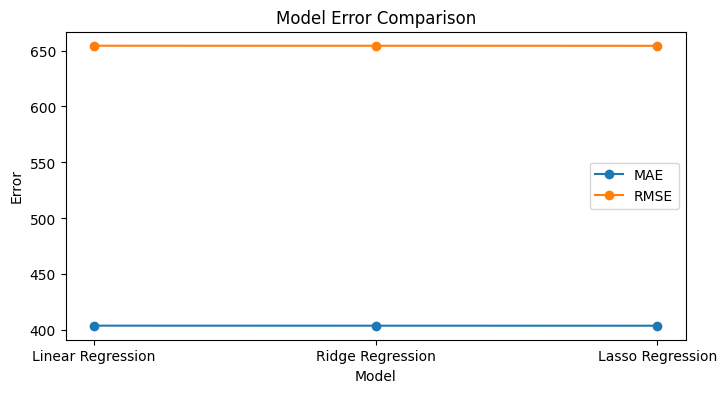

In [13]:
plot_df = results_df.set_index("model")[["MAE", "RMSE", "R2"]]

plt.figure(figsize=(8, 4))
plt.plot(plot_df.index, plot_df["MAE"], marker="o", label="MAE")
plt.plot(plot_df.index, plot_df["RMSE"], marker="o", label="RMSE")

plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.xlabel("Model")
plt.legend()
plt.show()

The error comparison plot shows that Linear Regression, Ridge Regression, and Lasso Regression have nearly identical test-set performance.

This supports the conclusion that regularization does not materially improve this simple baseline model.

## 11. Check Lasso Sparsity

In [14]:
num_lasso_zero = (coef_comparison["lasso_coef"] == 0).sum()  # Count coefficients set exactly to zero by Lasso

total_features = coef_comparison.shape[0]  # Count total transformed features

print("Number of Lasso coefficients set to zero:", num_lasso_zero)  # Display sparse coefficient count
print("Total number of features:", total_features)  # Display total feature count
print("Percent zeroed:", num_lasso_zero / total_features)  # Display share of features removed by Lasso

Number of Lasso coefficients set to zero: 0
Total number of features: 13
Percent zeroed: 0.0


## Lasso Sparsity Interpretation

With `alpha = 0.1`, Lasso did not set any coefficients exactly to zero.

This means the model did not perform feature selection at this regularization strength.

This does not prove that every feature is important. It only means the selected Lasso penalty was not strong enough to remove any features in this fitted model.

A future version could test multiple alpha values using cross-validation.

## 12. Findings

The purpose of this notebook was to compare baseline Linear Regression with Ridge and Lasso regularized regression for predicting monthly member cost.

The target variable was `monthly_cost`.

The predictor set excluded `member_id`, `high_cost_member`, and `awv_completed`. `member_id` was excluded because it is only an identifier. `high_cost_member` was excluded because it is derived from `monthly_cost` and would create target leakage. `awv_completed` was excluded to keep the baseline cost prediction model focused on member characteristics, risk, access, and utilization.

Ridge and Lasso were introduced to control coefficient size and reduce overfitting pressure relative to baseline Linear Regression.

Ridge uses L2 regularization, which generally shrinks coefficients toward zero without removing most predictors completely.

Lasso uses L1 regularization, which can shrink some coefficients exactly to zero. This creates a sparse model, but a zero coefficient should not be interpreted as proof that the feature is universally irrelevant.

The models were evaluated using MAE, RMSE, and R². If Ridge or Lasso performs similarly to Linear Regression, that may suggest some redundancy or coefficient instability in the baseline model. If regularization improves test performance, it suggests shrinkage helped generalization in this synthetic dataset.

Regularized coefficients are still conditional model-based associations, not causal effects.

Because this is synthetic data, the observed relationships reflect the assumptions built into the data-generation process and should not be interpreted as real-world causal evidence.

In this notebook, Ridge and Lasso performed almost identically to baseline Linear Regression. The tiny metric differences are not practically meaningful.

Lasso did not remove any features at `alpha = 0.1`, so this model should not be described as sparse.

The next improvement would be to use `RidgeCV` and `LassoCV` to select alpha through cross-validation rather than choosing alpha manually.